In [60]:
import os
import re
import glob
import json
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ========= 配置 =========
ROOT = "./results_needle"     # 你的 output_dir
# ROOT = "./results_needle_guhao"     # 你的 output_dir
OUT_DIR = "./niah_plots_guhao"
os.makedirs(OUT_DIR, exist_ok=True)

# 你实验扫的网格（按你现在跑 1k~12.5k）
CONTEXTS = [1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000,10500,11000,11500,12000,12500]
DEPTHS   = [15,25,35,45,55,65,75,85,95]

# 目录名解析：needle_in_haystack__...__<press>__cr0.50__max_context12500__needle_depth75
# DIR_RE = re.compile(
#     r"needle_in_haystack__.*?__(?P<press>.+?)__cr(?P<cr>\d+\.\d+)__.*?max_context(?P<ctx>\d+)__.*?needle_depth(?P<depth>\d+)"
# )
DIR_RE = re.compile(
    r"needle_in_haystack__"
    r"(?P<model>.+?)__"
    r"(?P<press>.+?)__"
    r"cr(?P<cr>\d+\.\d+)__"
    r".*?max_context(?P<ctx>\d+)__"
    r".*?needle_depth(?P<depth>\d+)"
)

def find_metrics_json(run_dir: str) -> str | None:
    """
    递归找 metrics*.json。兼容：
      run_dir/metrics.json
      run_dir/1/metrics.json
      run_dir/**/metrics*.json
    """
    cand = glob.glob(os.path.join(run_dir, "**", "metrics*.json"), recursive=True)
    if not cand:
        return None
    # 选最短路径的一份（通常就是最外层或 /1/ 层）
    cand.sort(key=lambda p: (p.count(os.sep), len(p)))
    return cand[0]

def rougeL_f_from_metrics(metrics_path: str) -> float:
    """
    你的 metrics.json 结构示例是 list[dict]，其中 rouge-l: {r,p,f}
    返回 rouge-l 的 f (float)。取不到就返回 NaN。
    """
    obj = json.load(open(metrics_path, "r"))

    if isinstance(obj, list):
        obj = obj[0] if obj else {}

    rl = obj.get("rouge-l", None)
    if isinstance(rl, dict) and "f" in rl:
        return float(rl["f"])

    return float("nan")



In [61]:
press_map = {
    "query_indexer_kvzip_max": "IndexMem",
    "expected_attention": "ExpectedAttention",
    "tova": "TOVA",
    "snapkv": "SnapKV",
    "pyramidkv": "PyramidKV",
    "query_indexer_max_mode": "Indexer only",
    "memory_query_indexer_max": "Indexer + Mem",
}


[INFO] collected points: 4414
[INFO] score stats (non-nan): count    3917.000000
mean        0.617900
std         0.177419
min         0.050000
25%         0.571429
50%         0.709677
75%         0.750000
max         0.850000
[DEBUG] press=expected_attention cr=0.10 filled=216/216 unique(non-nan)=[0.70967741 0.75      ]
[DEBUG] press=expected_attention cr=0.25 filled=216/216 unique(non-nan)=[0.57142857 0.62068965 0.70967741 0.75      ]
[DEBUG] press=expected_attention cr=0.50 filled=216/216 unique(non-nan)=[0.26086956 0.33333333 0.46153846 0.4680851  0.48780487 0.5
 0.51851851 0.52631578 0.53658536 0.55813953]...
[DEBUG] press=expected_attention cr=0.75 filled=216/216 unique(non-nan)=[0.15094339 0.15686274 0.1632653  0.16666666 0.17021276 0.17391304
 0.17777777 0.18604651 0.19230769 0.2051282 ]...
[DEBUG] press=expected_attention cr=0.90 filled=209/216 unique(non-nan)=[0.08       0.08163265 0.08695652 0.09523809 0.12244897 0.125
 0.12765957 0.13043478 0.14285714 0.14814814]...
[DEBUG

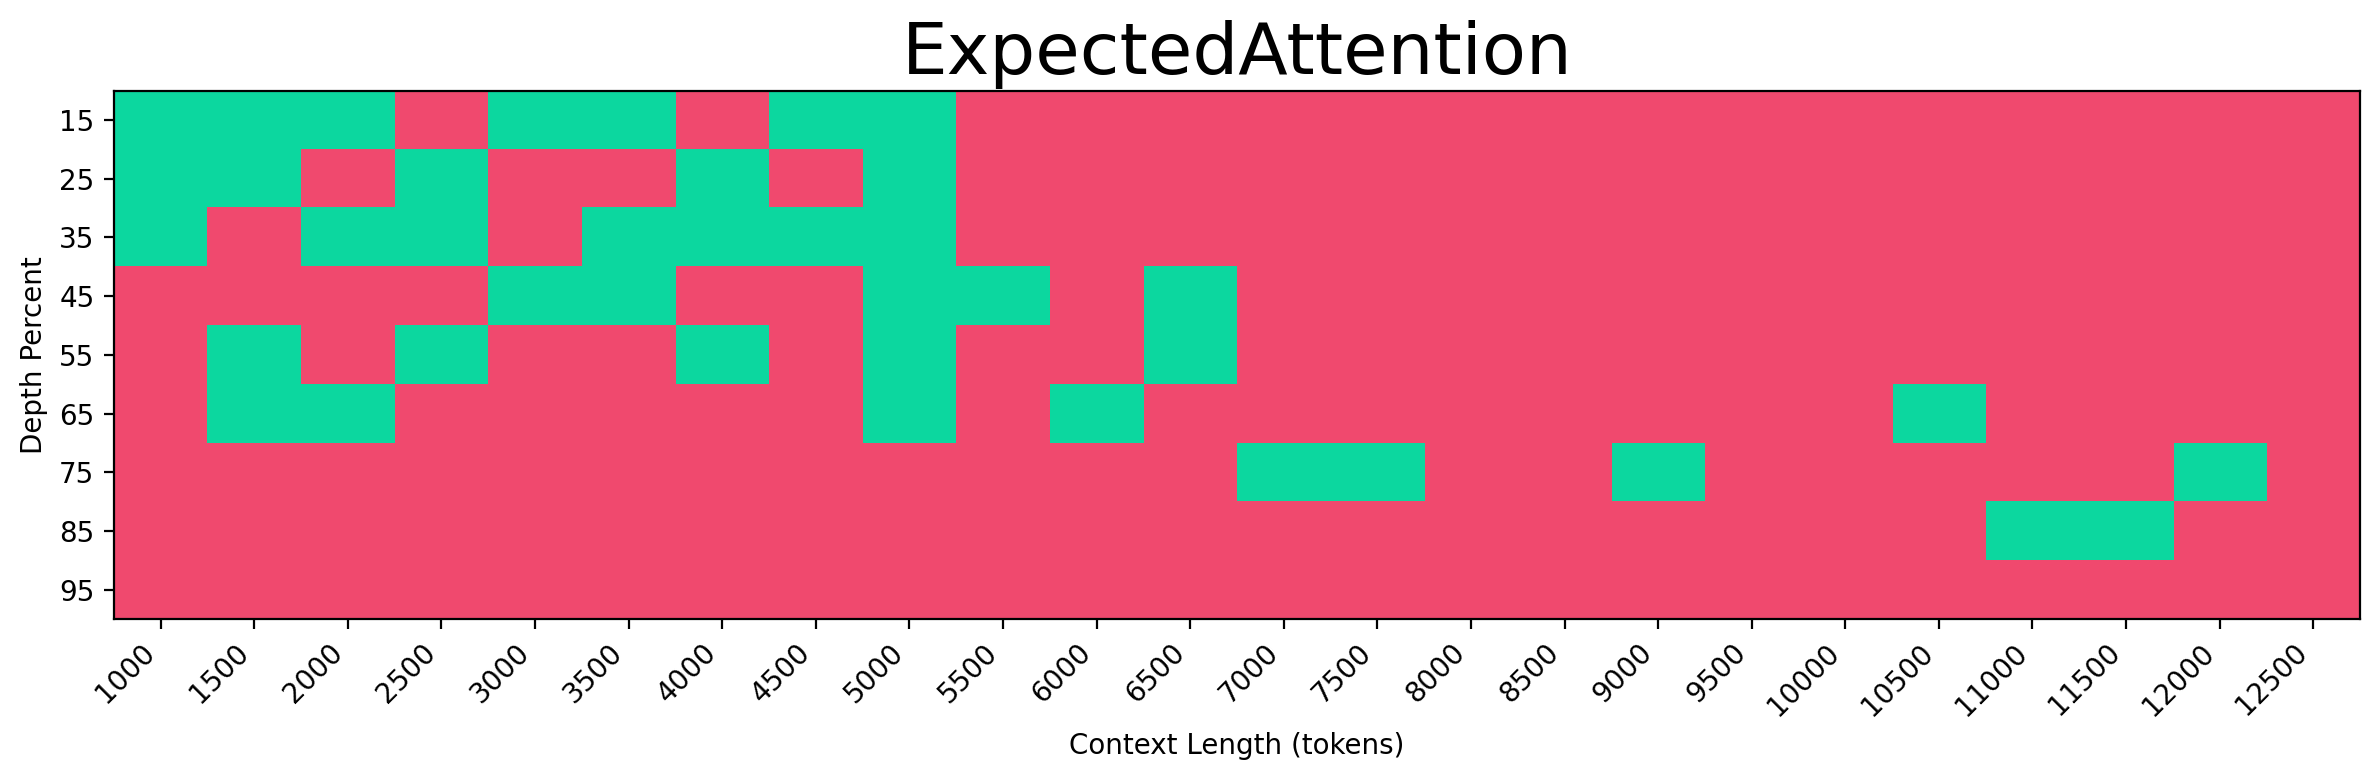

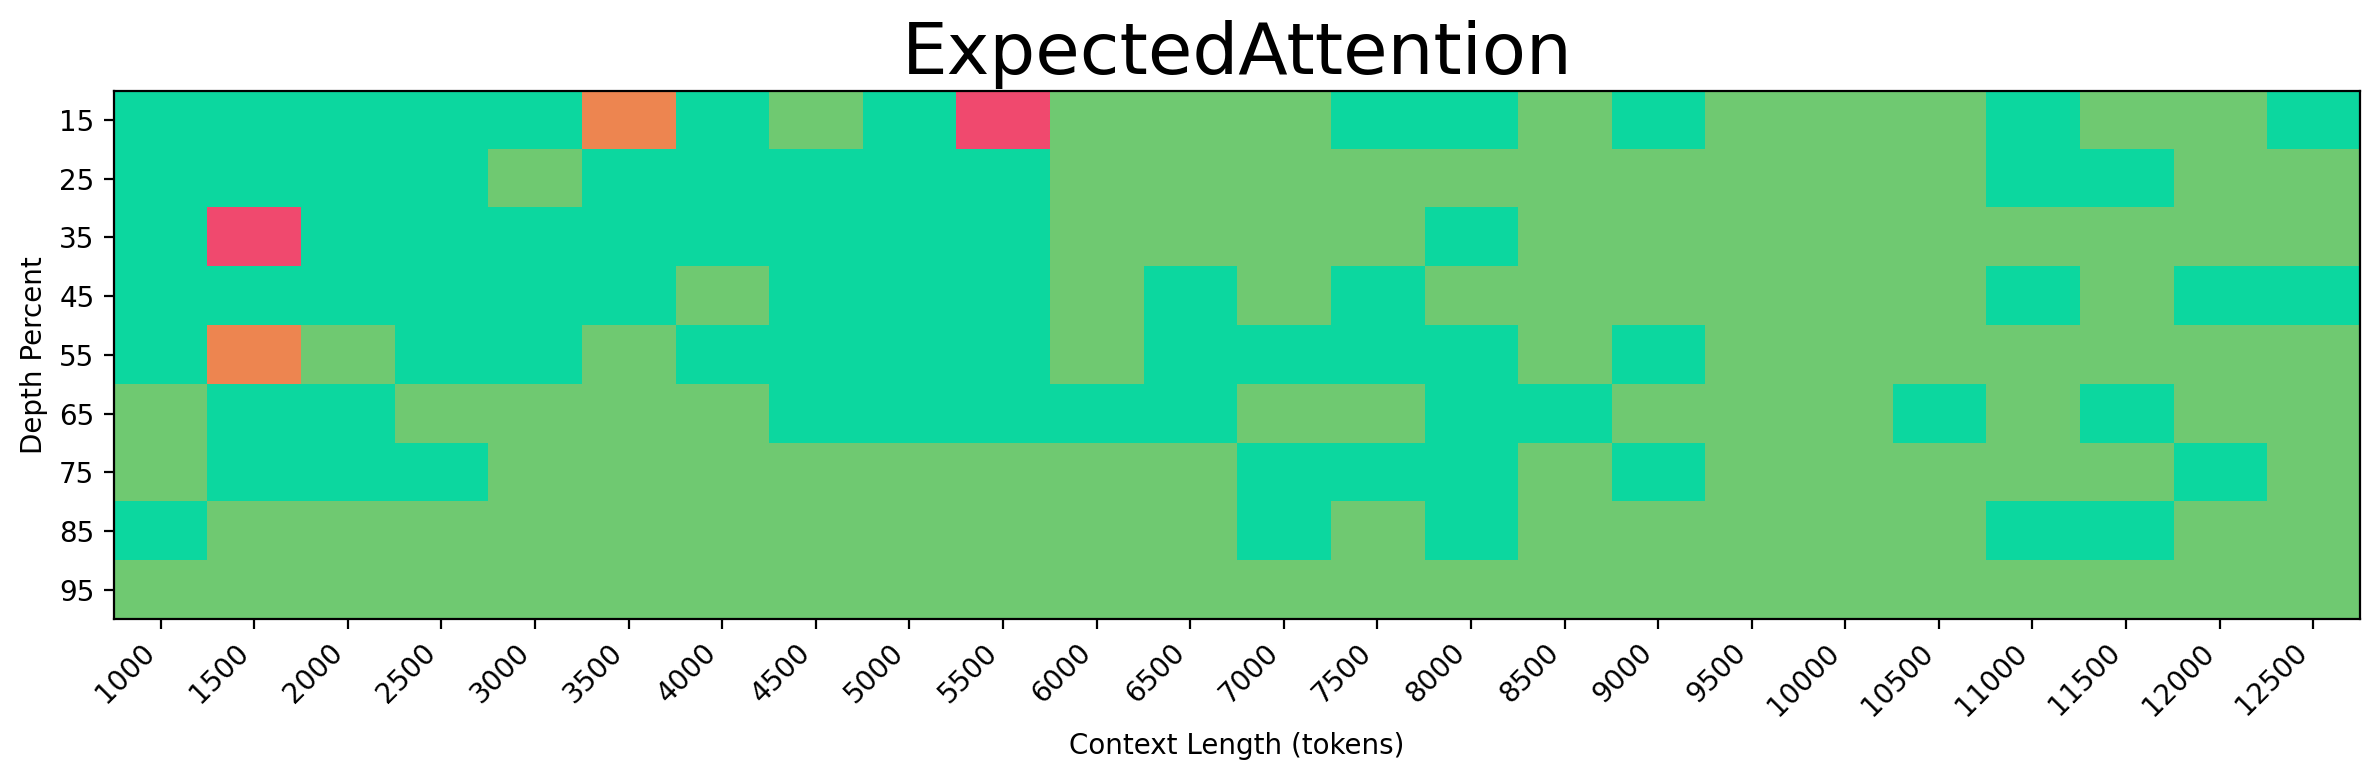

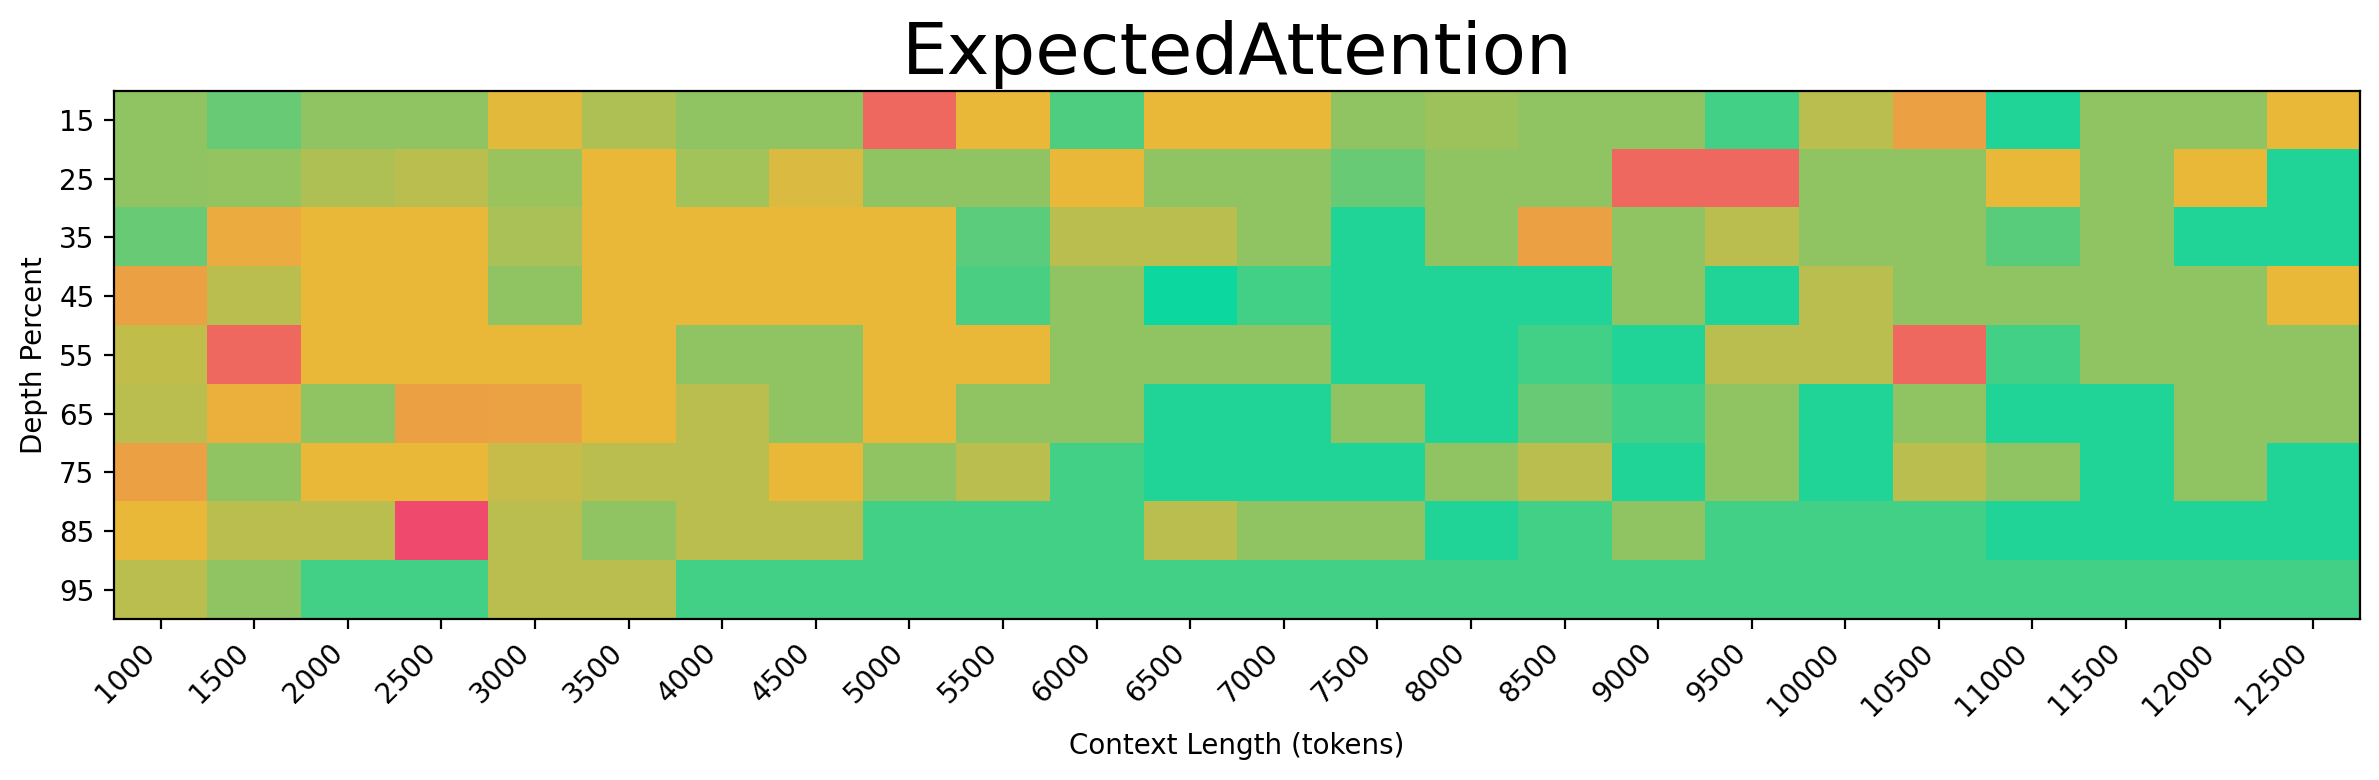

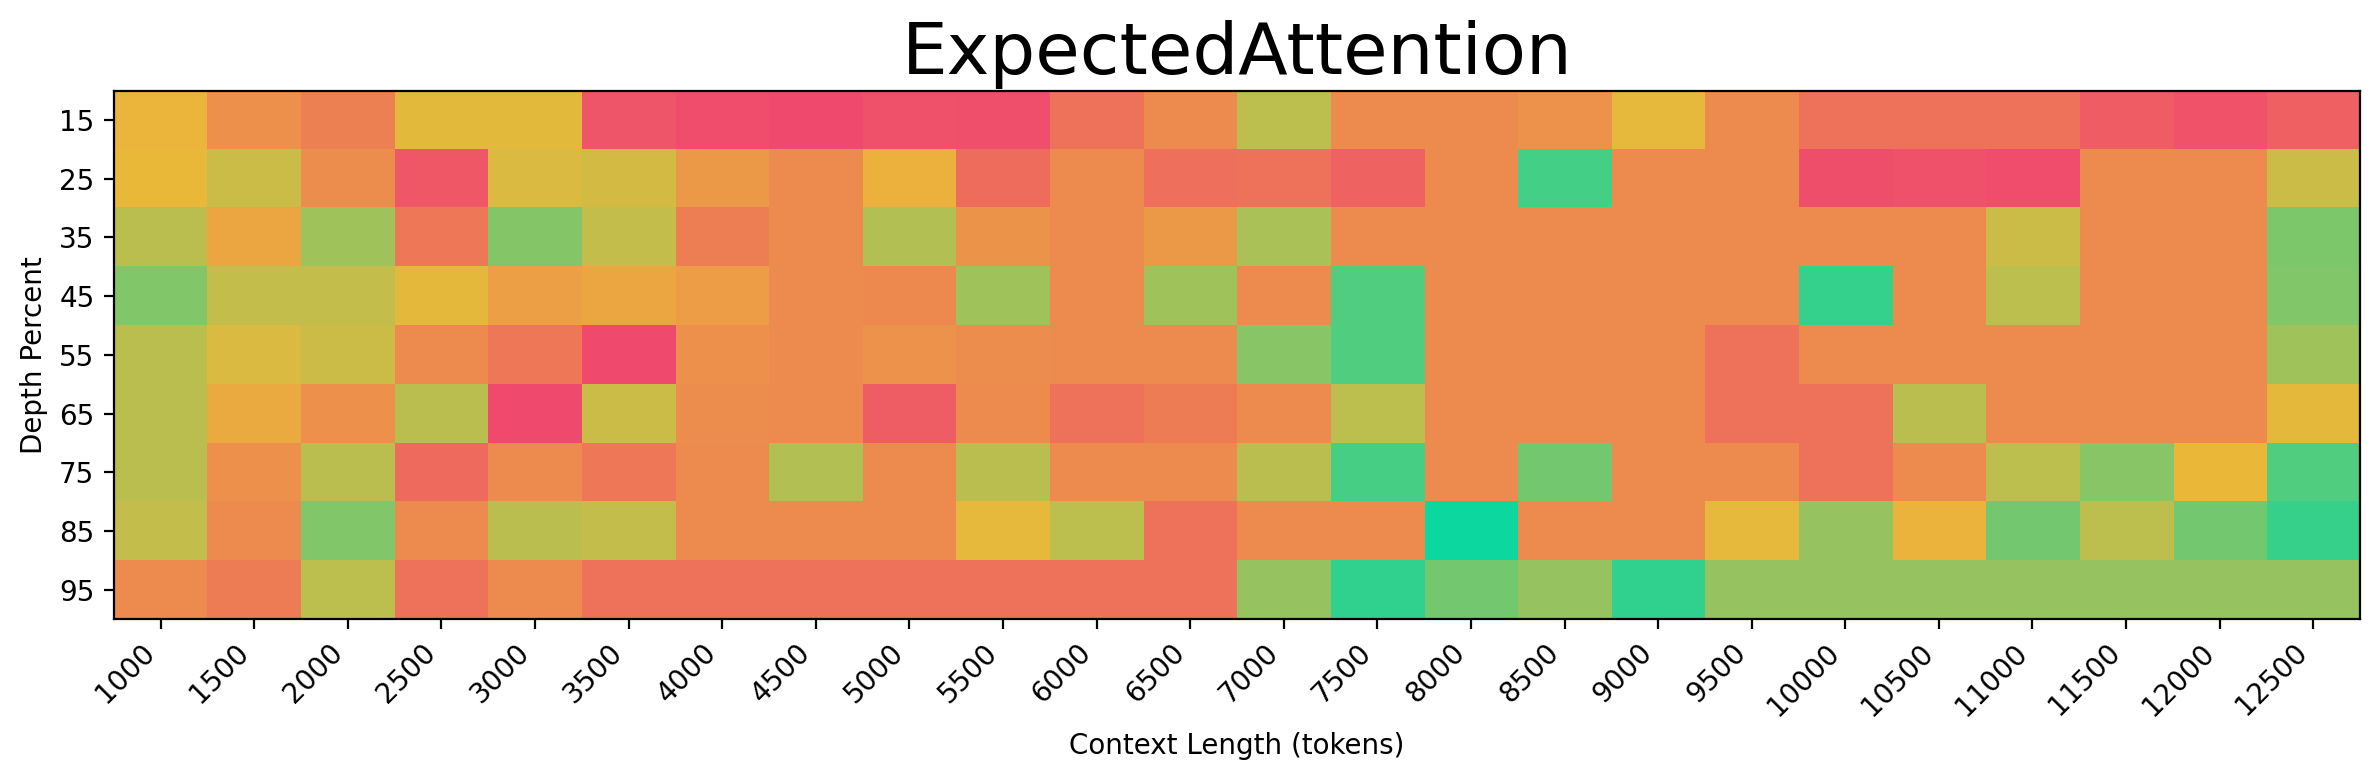

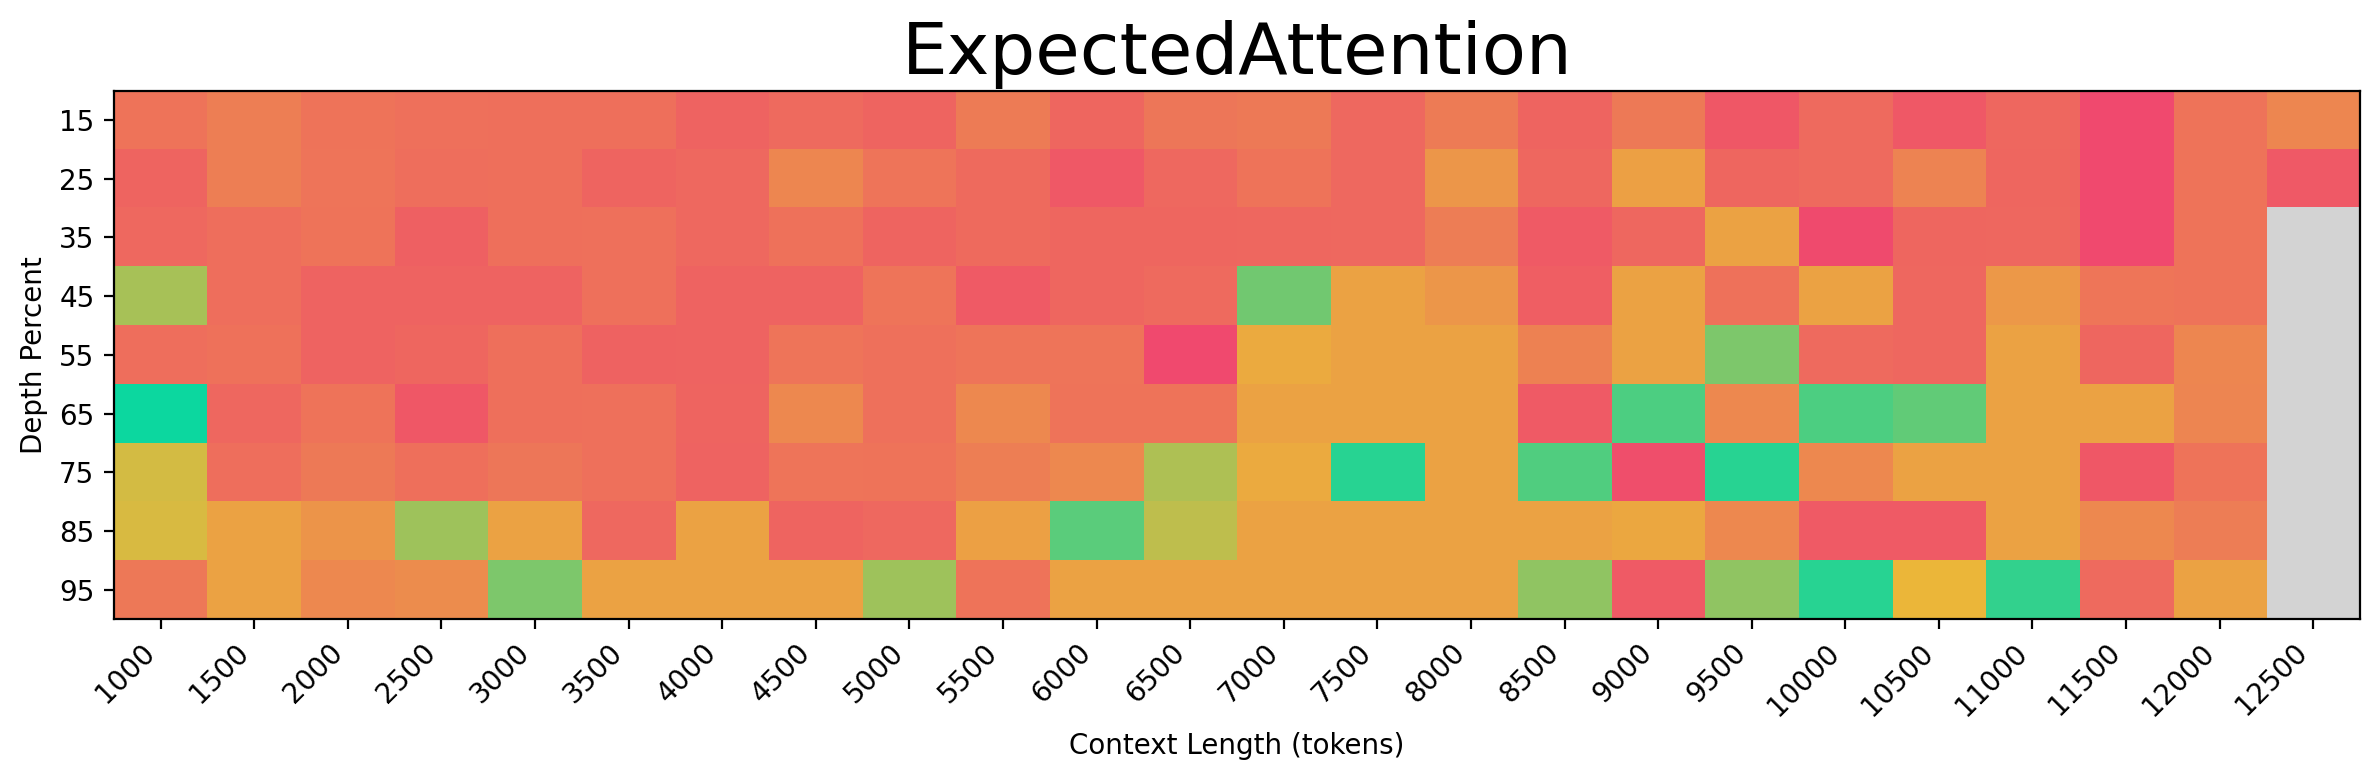

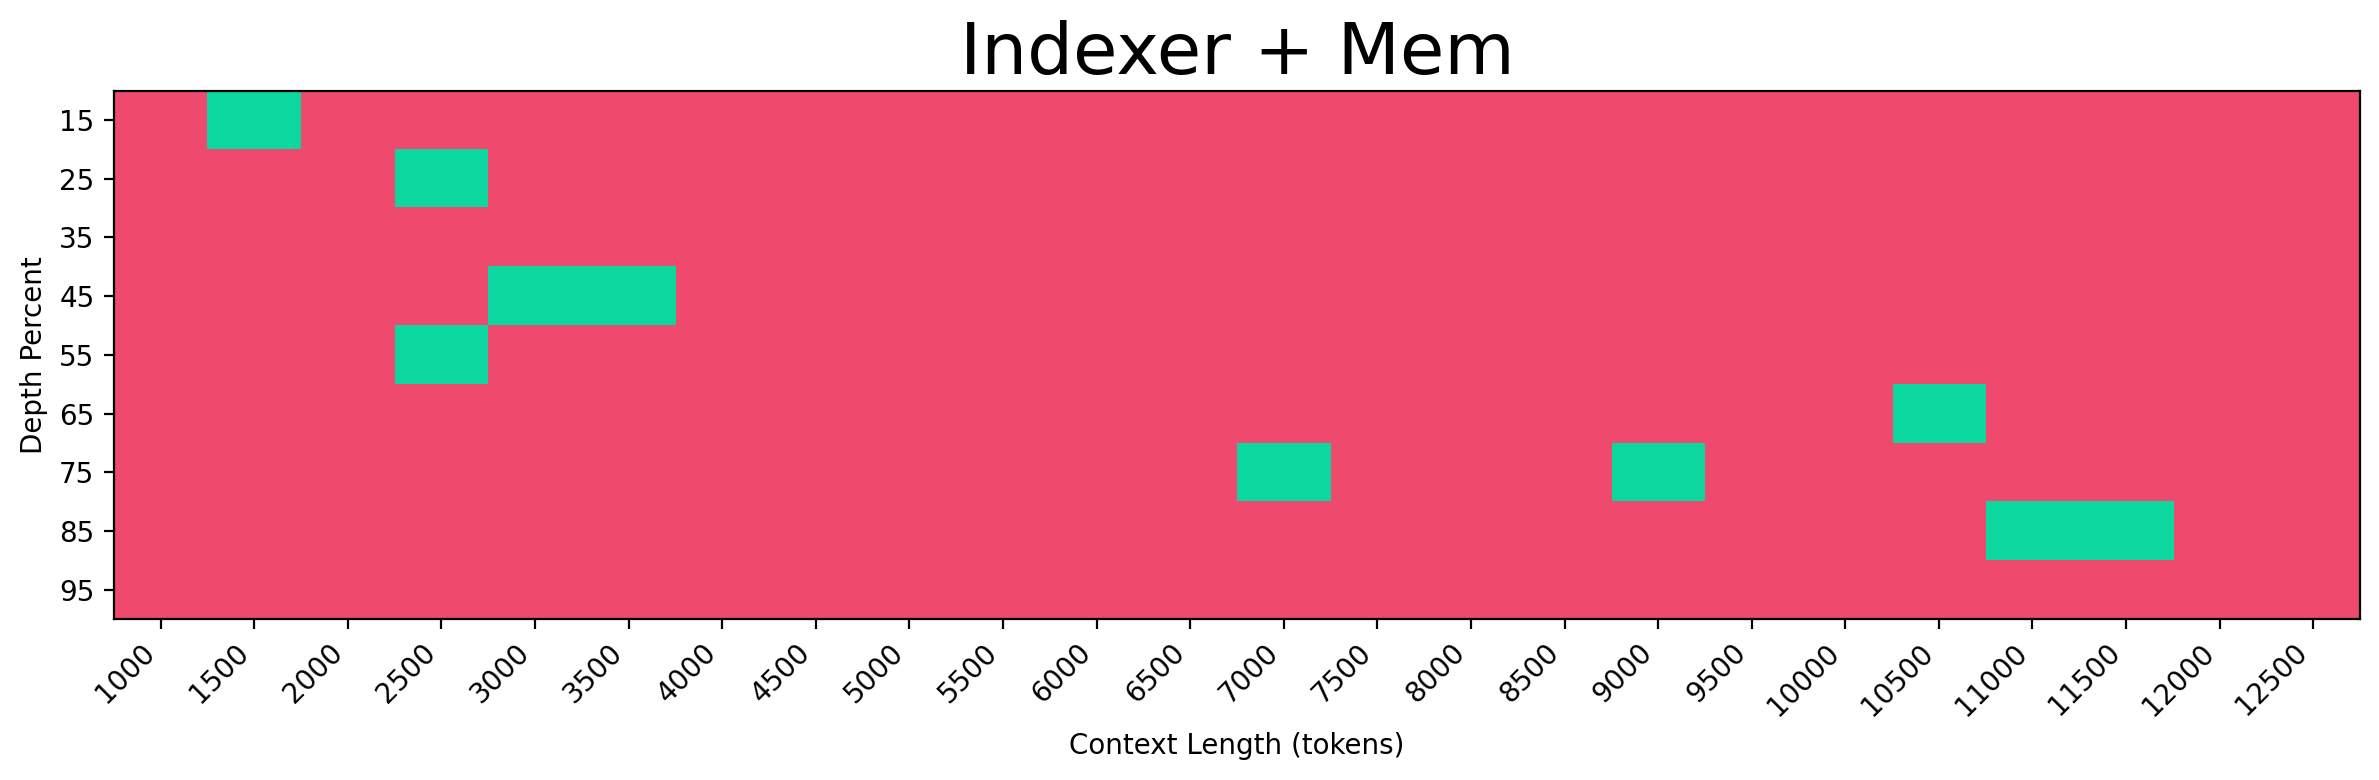

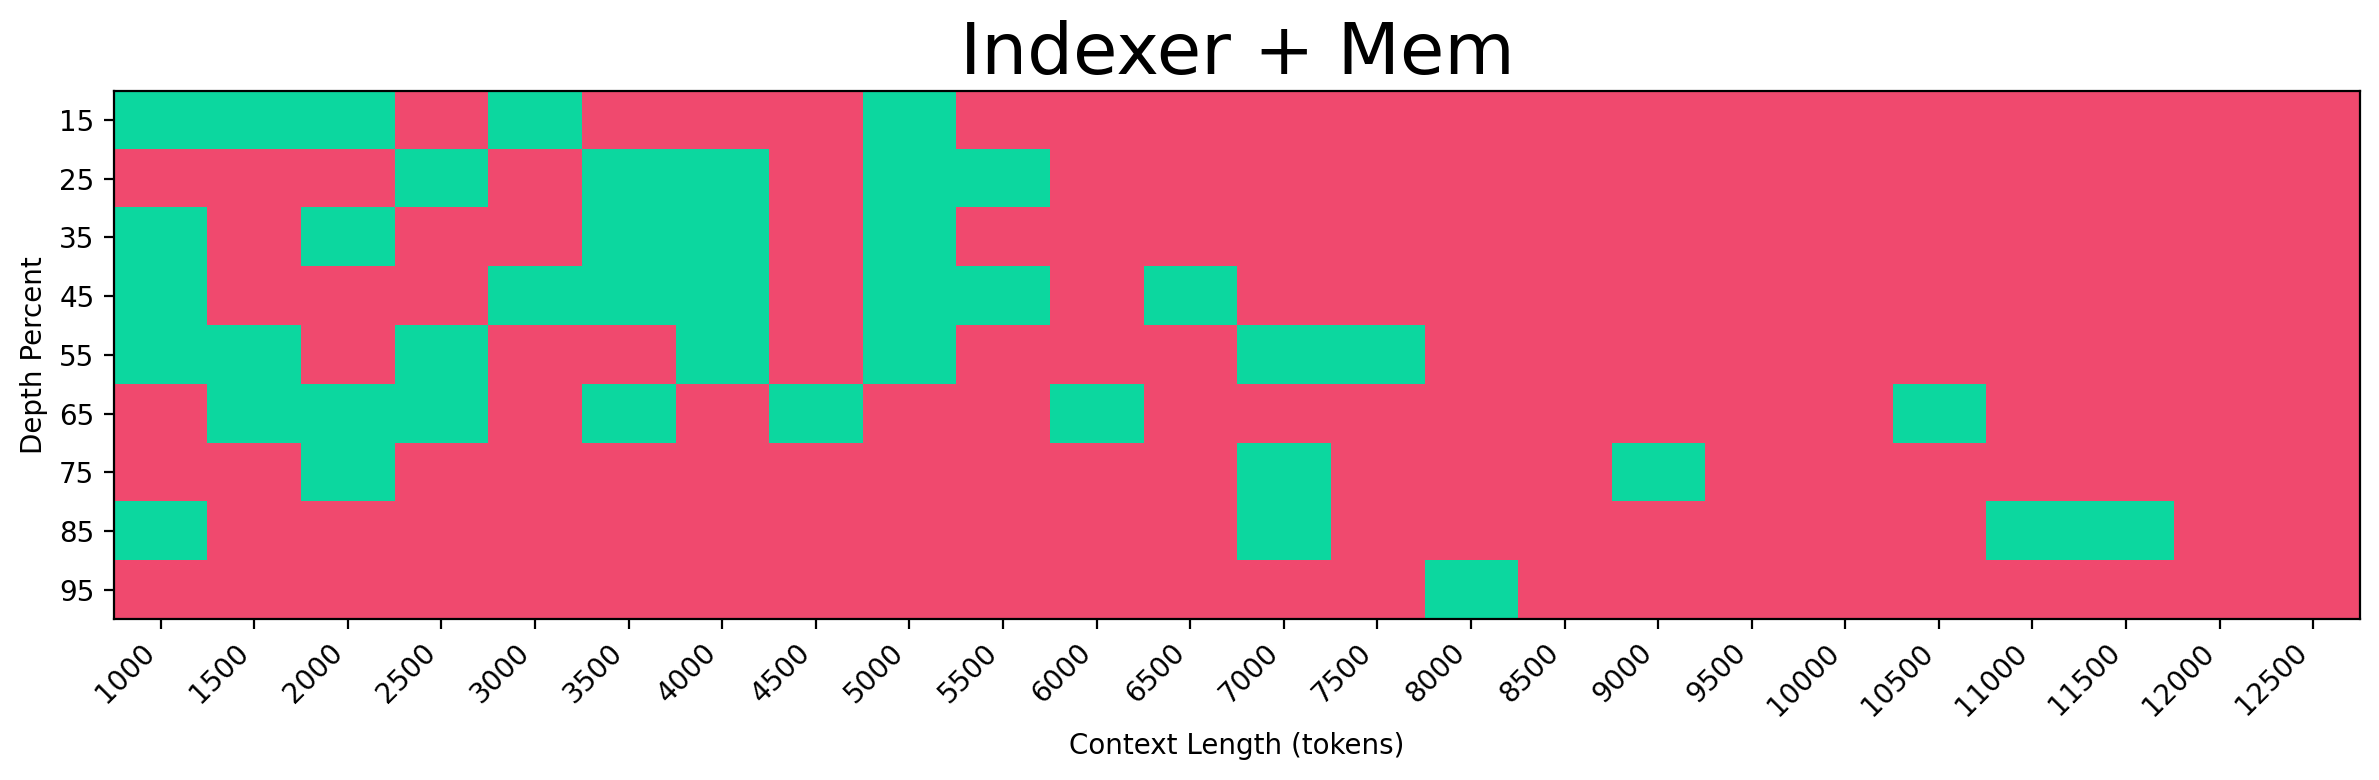

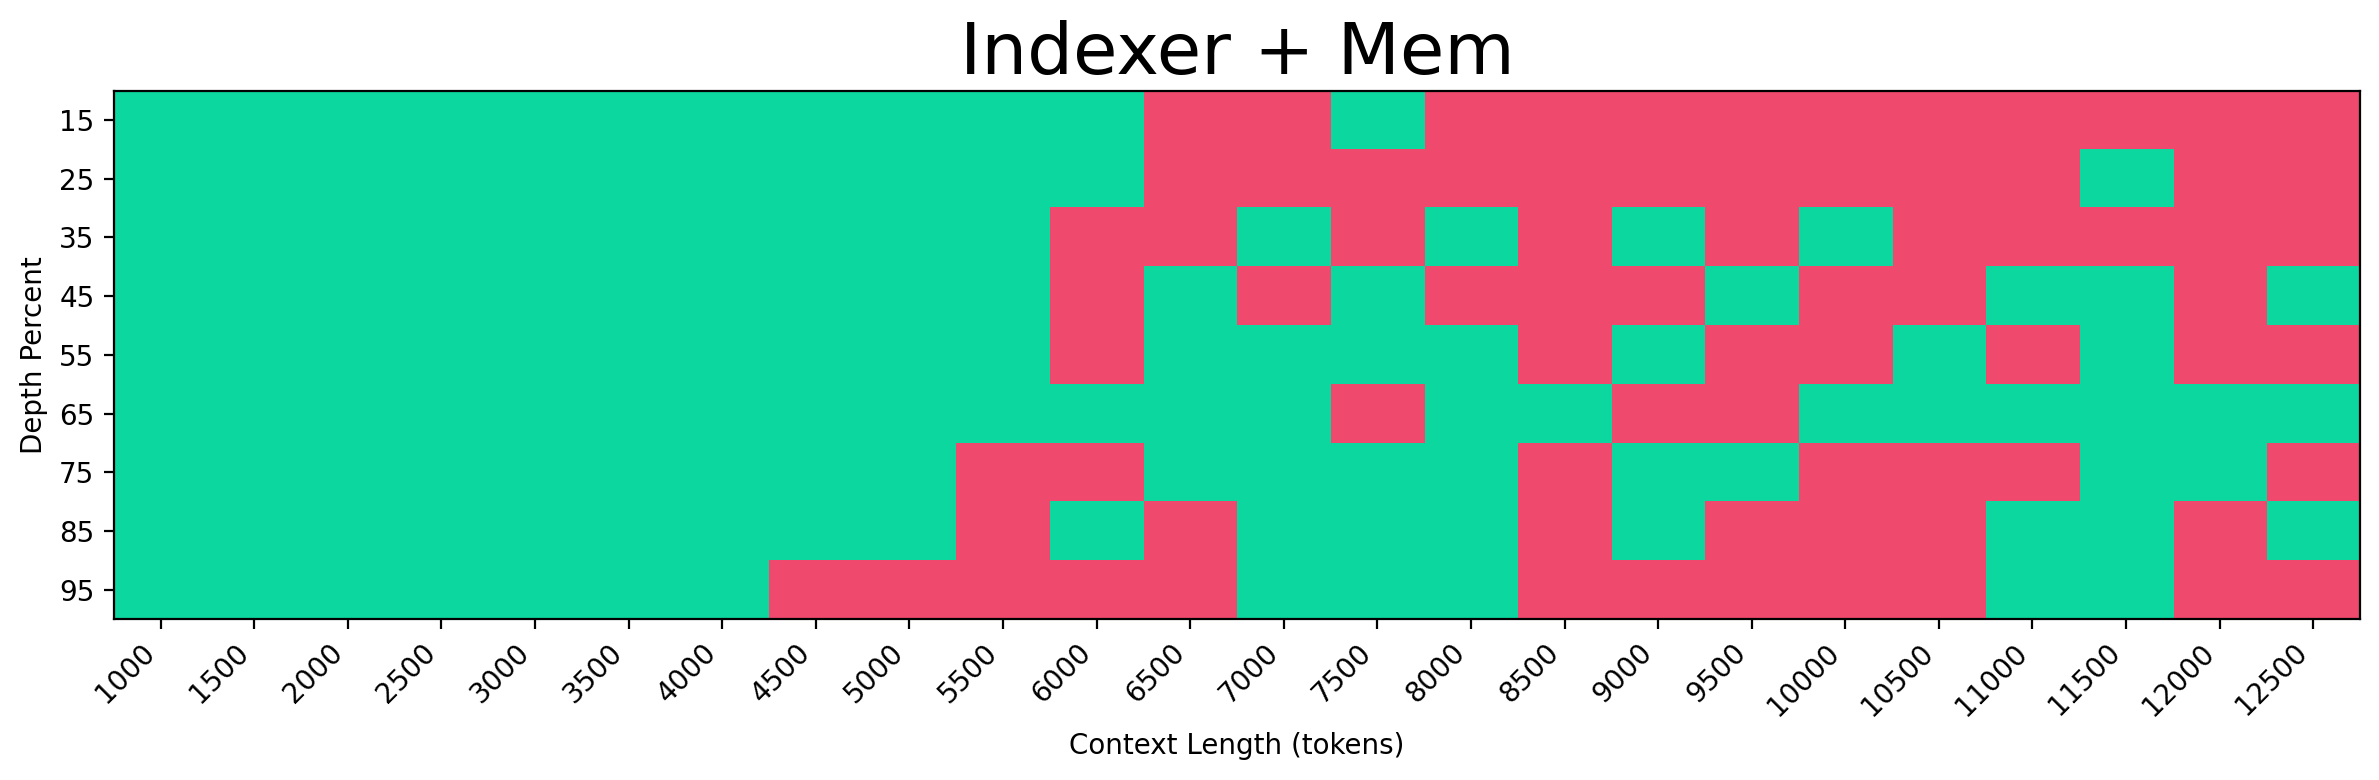

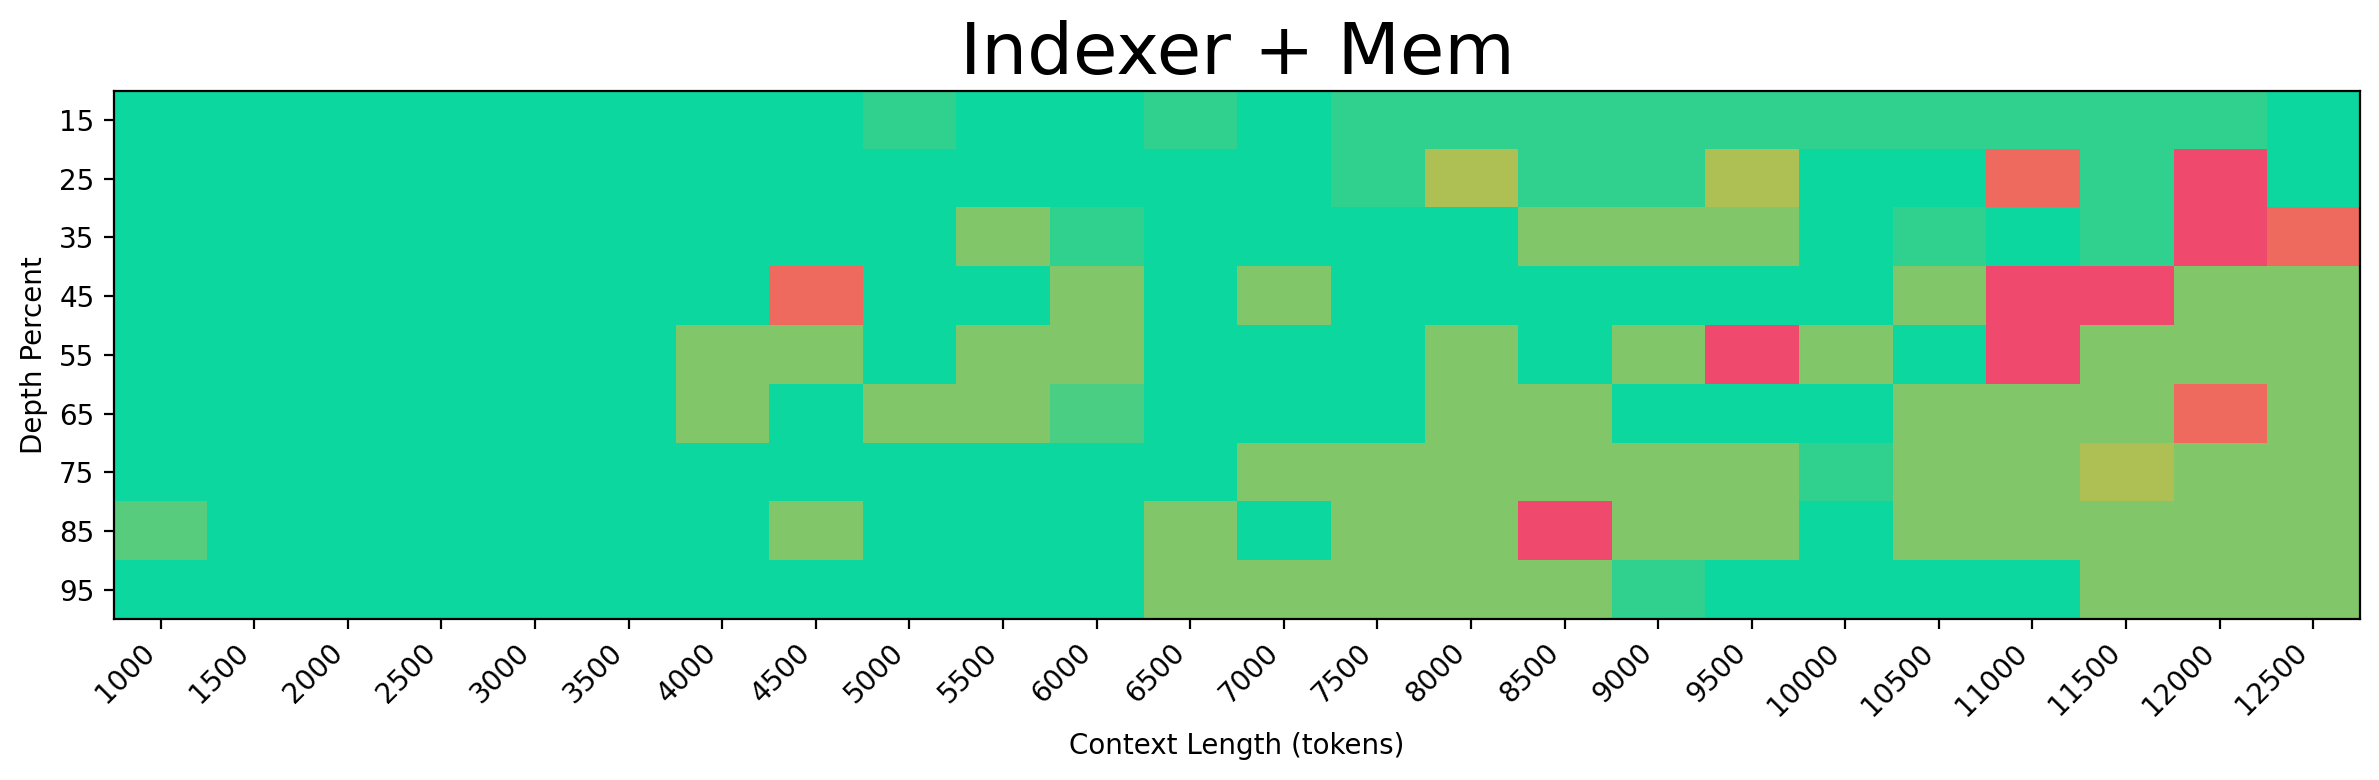

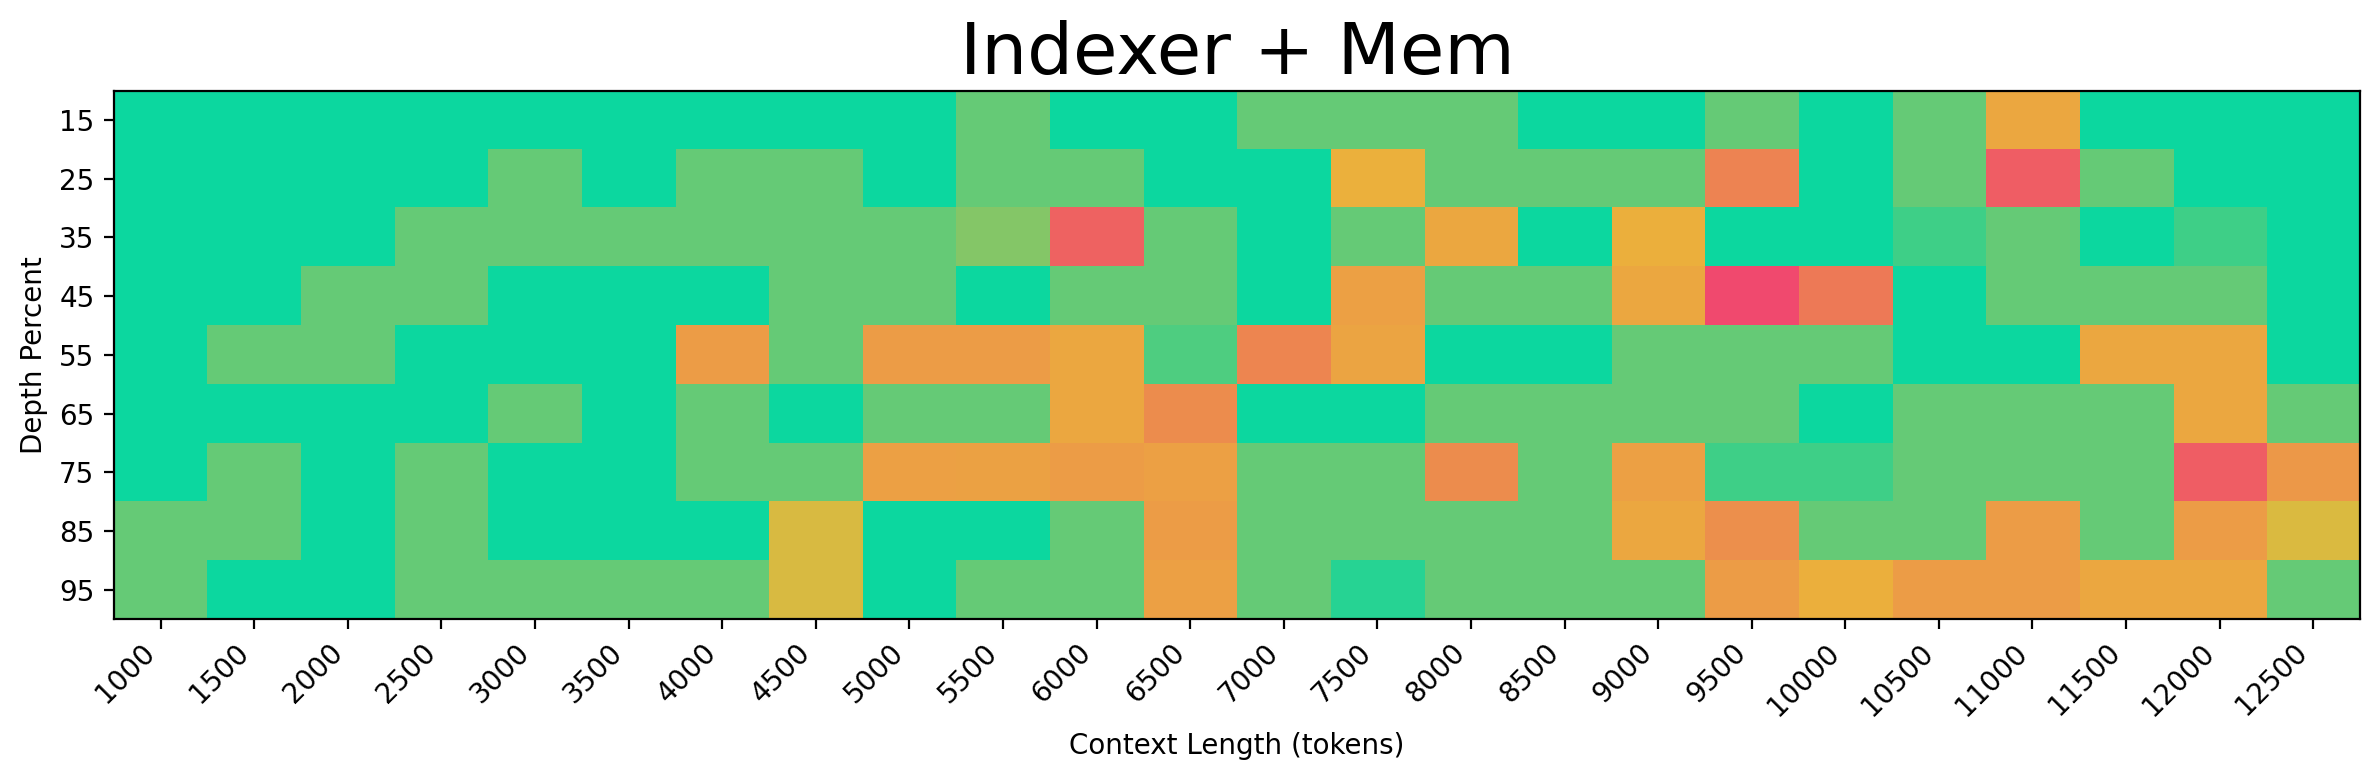

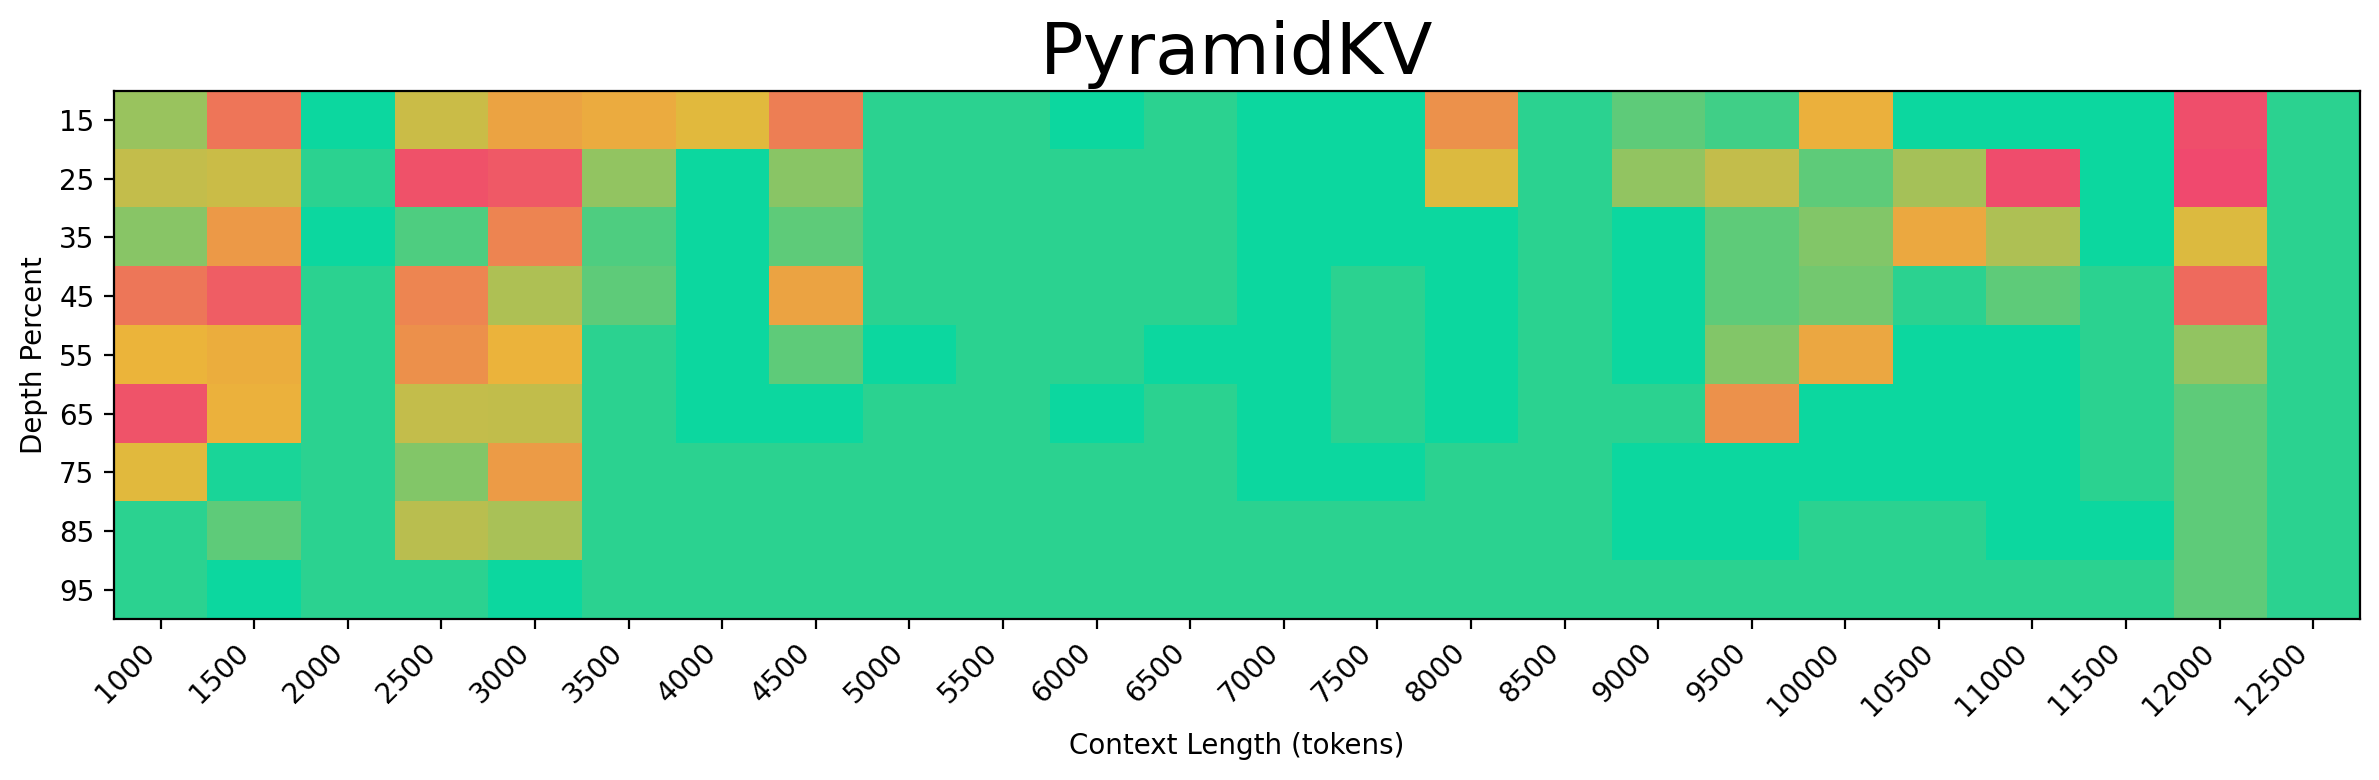

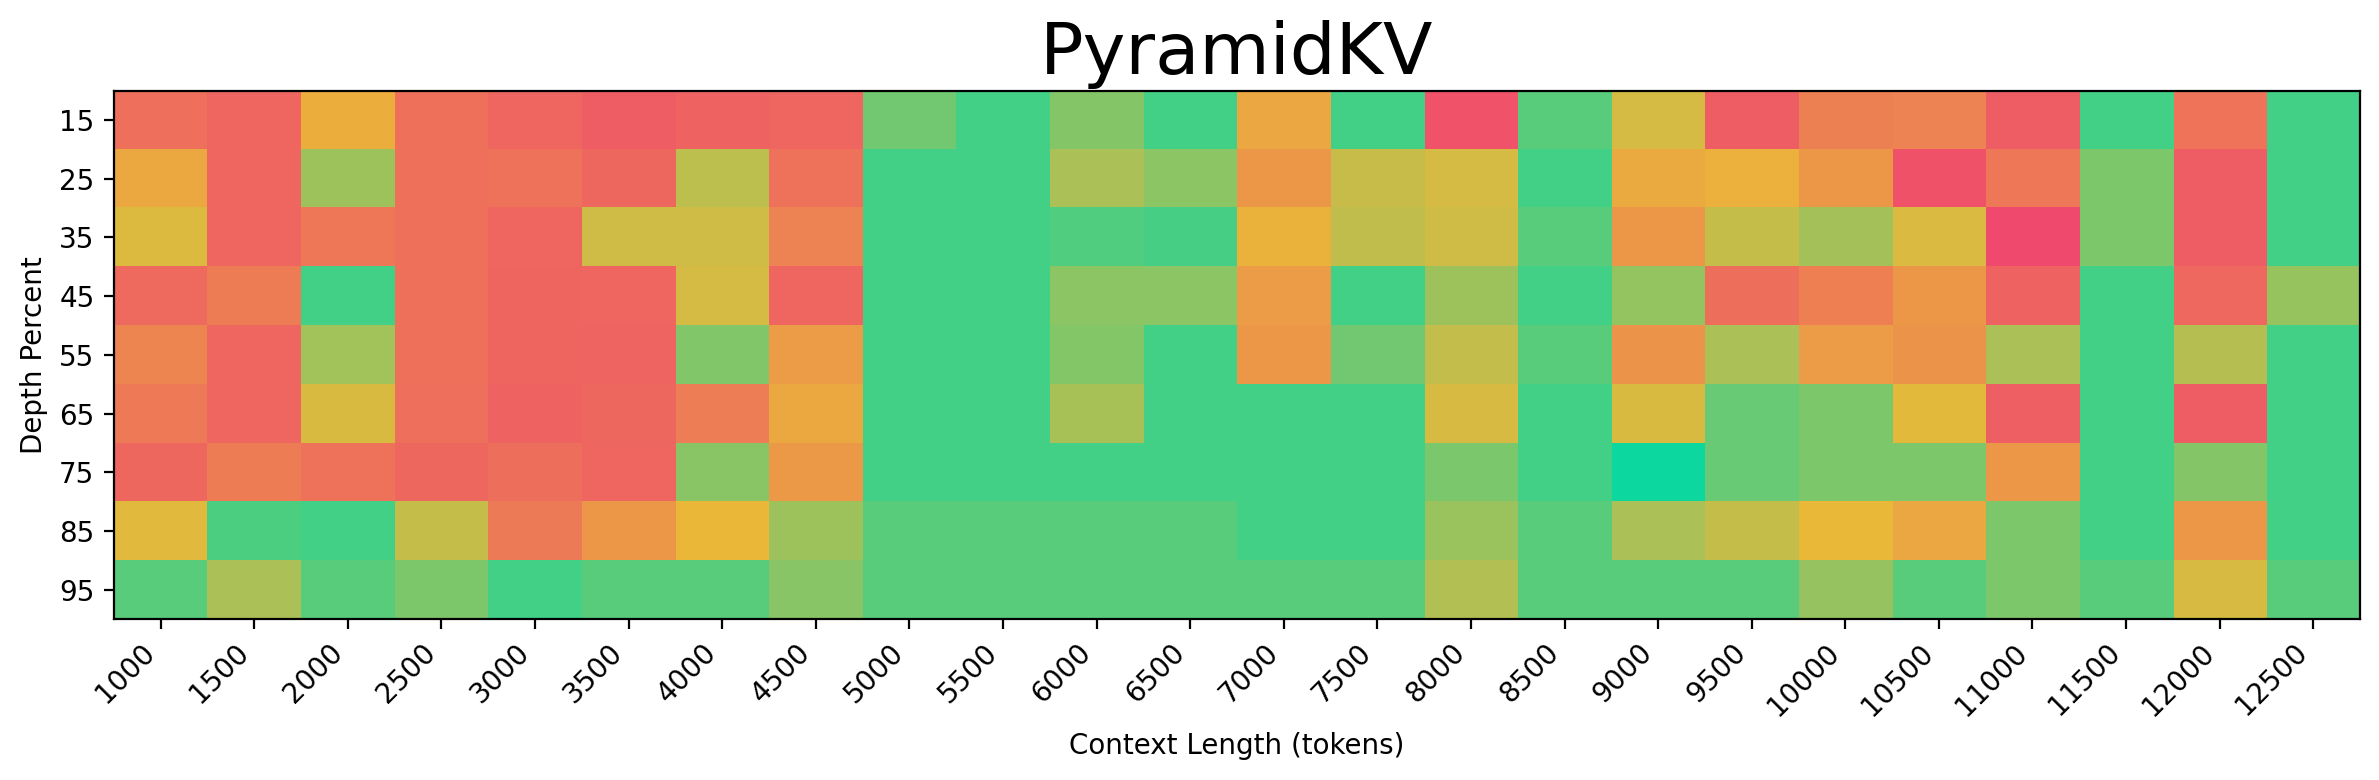

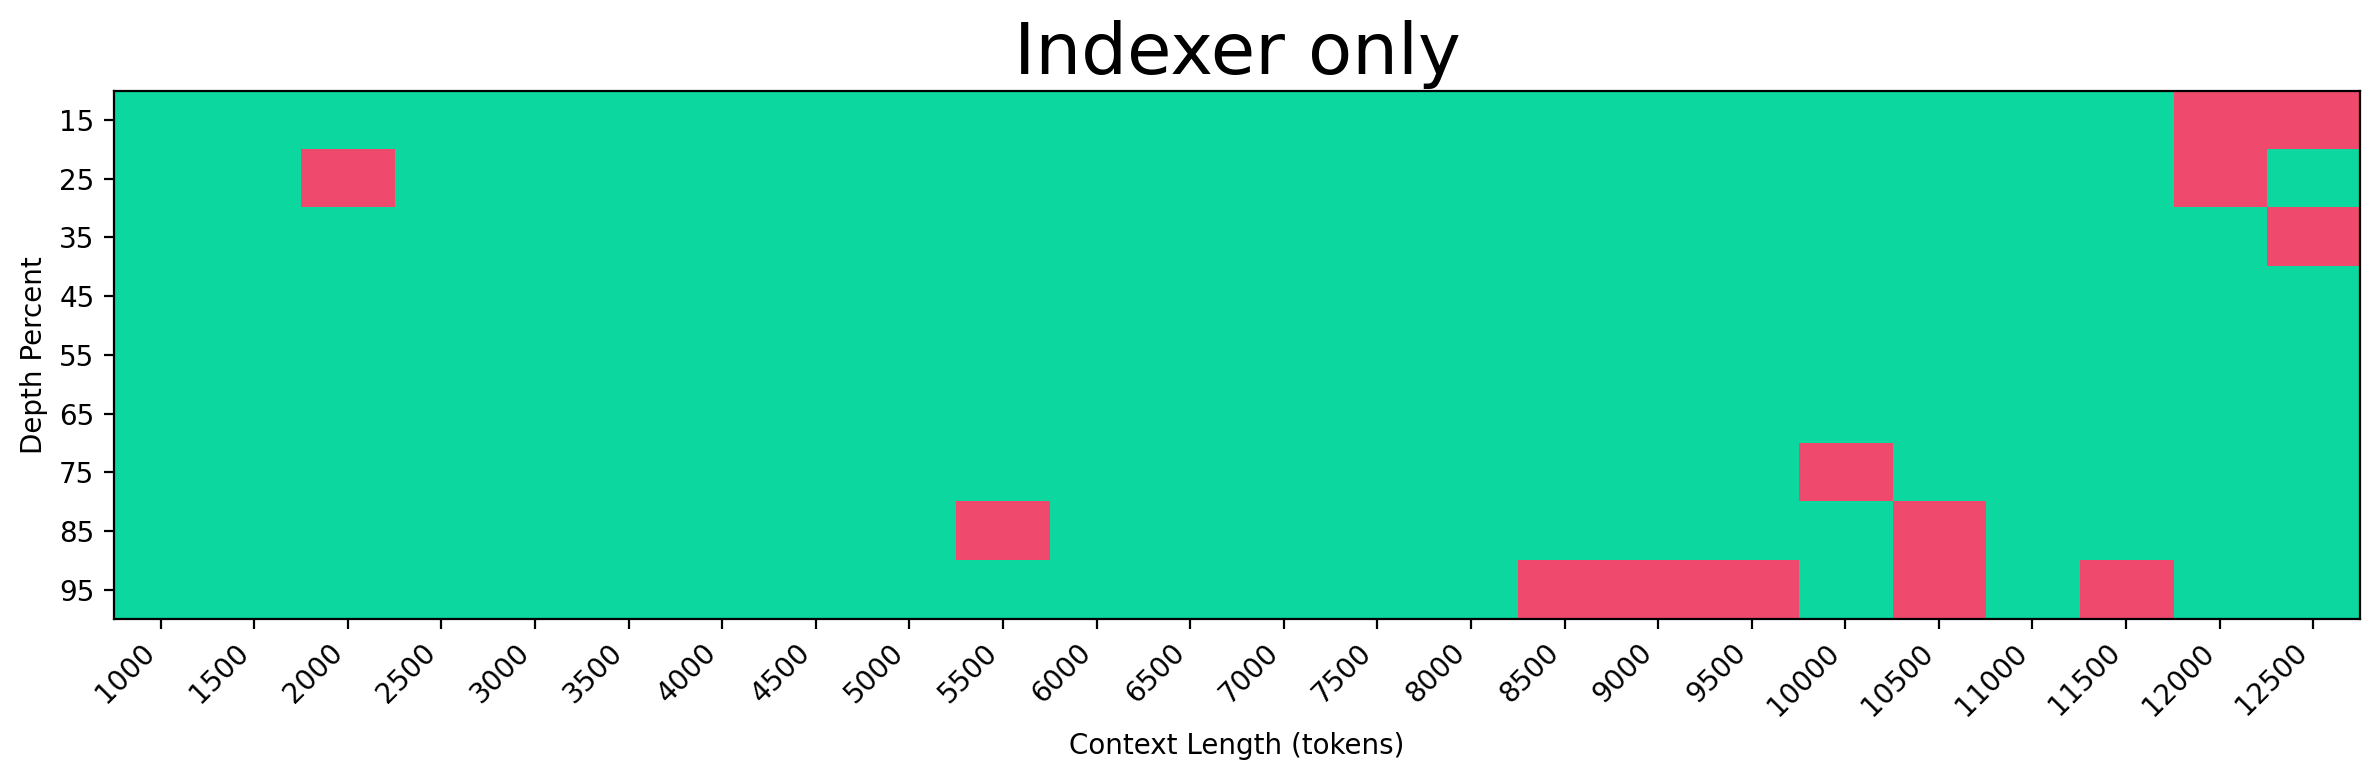

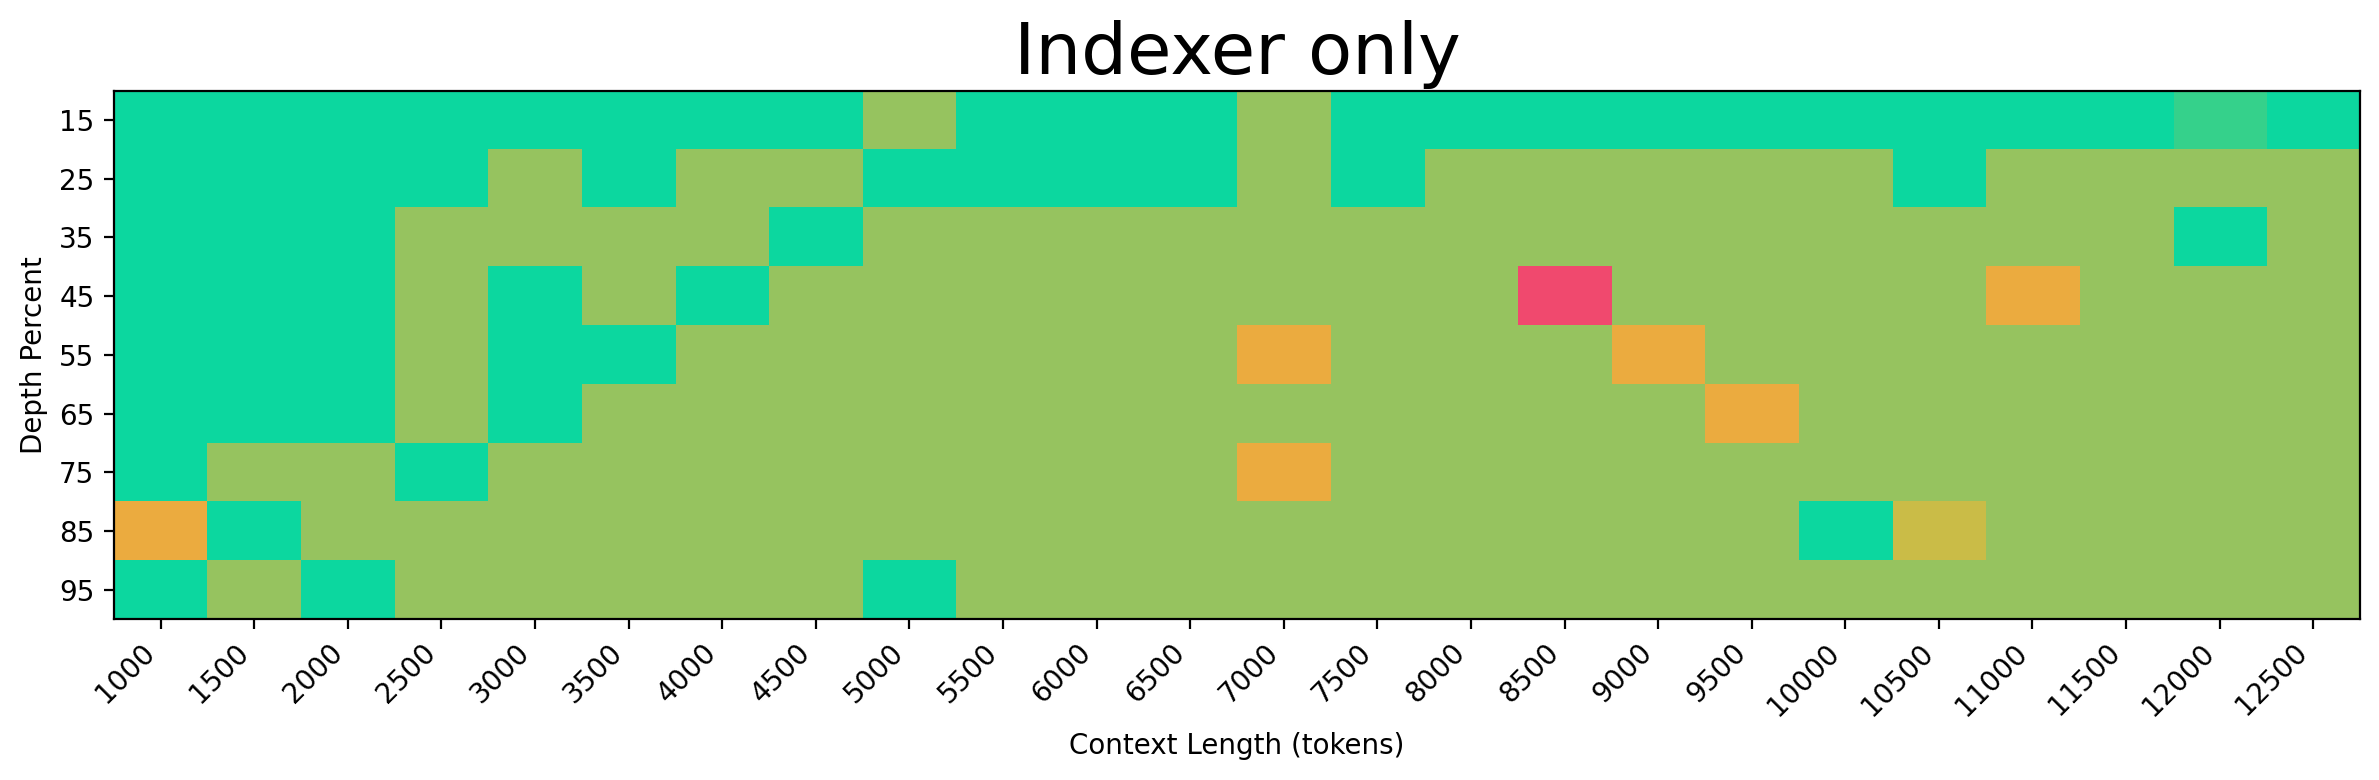

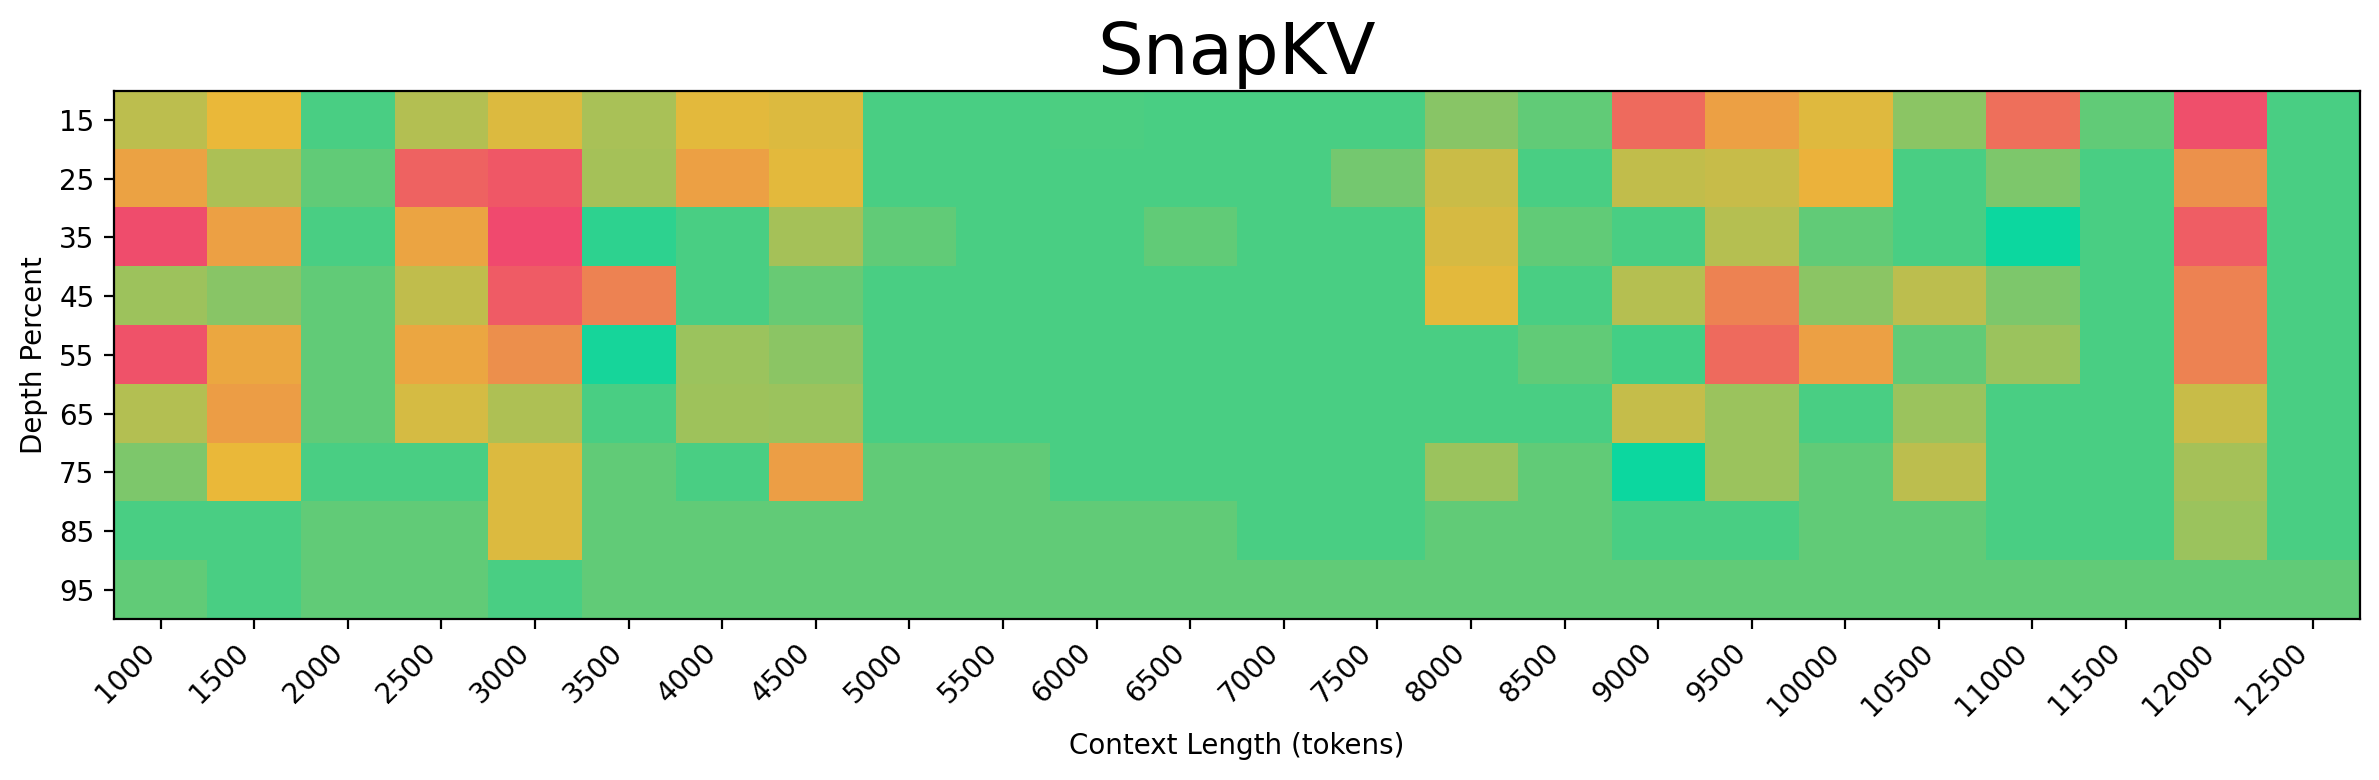

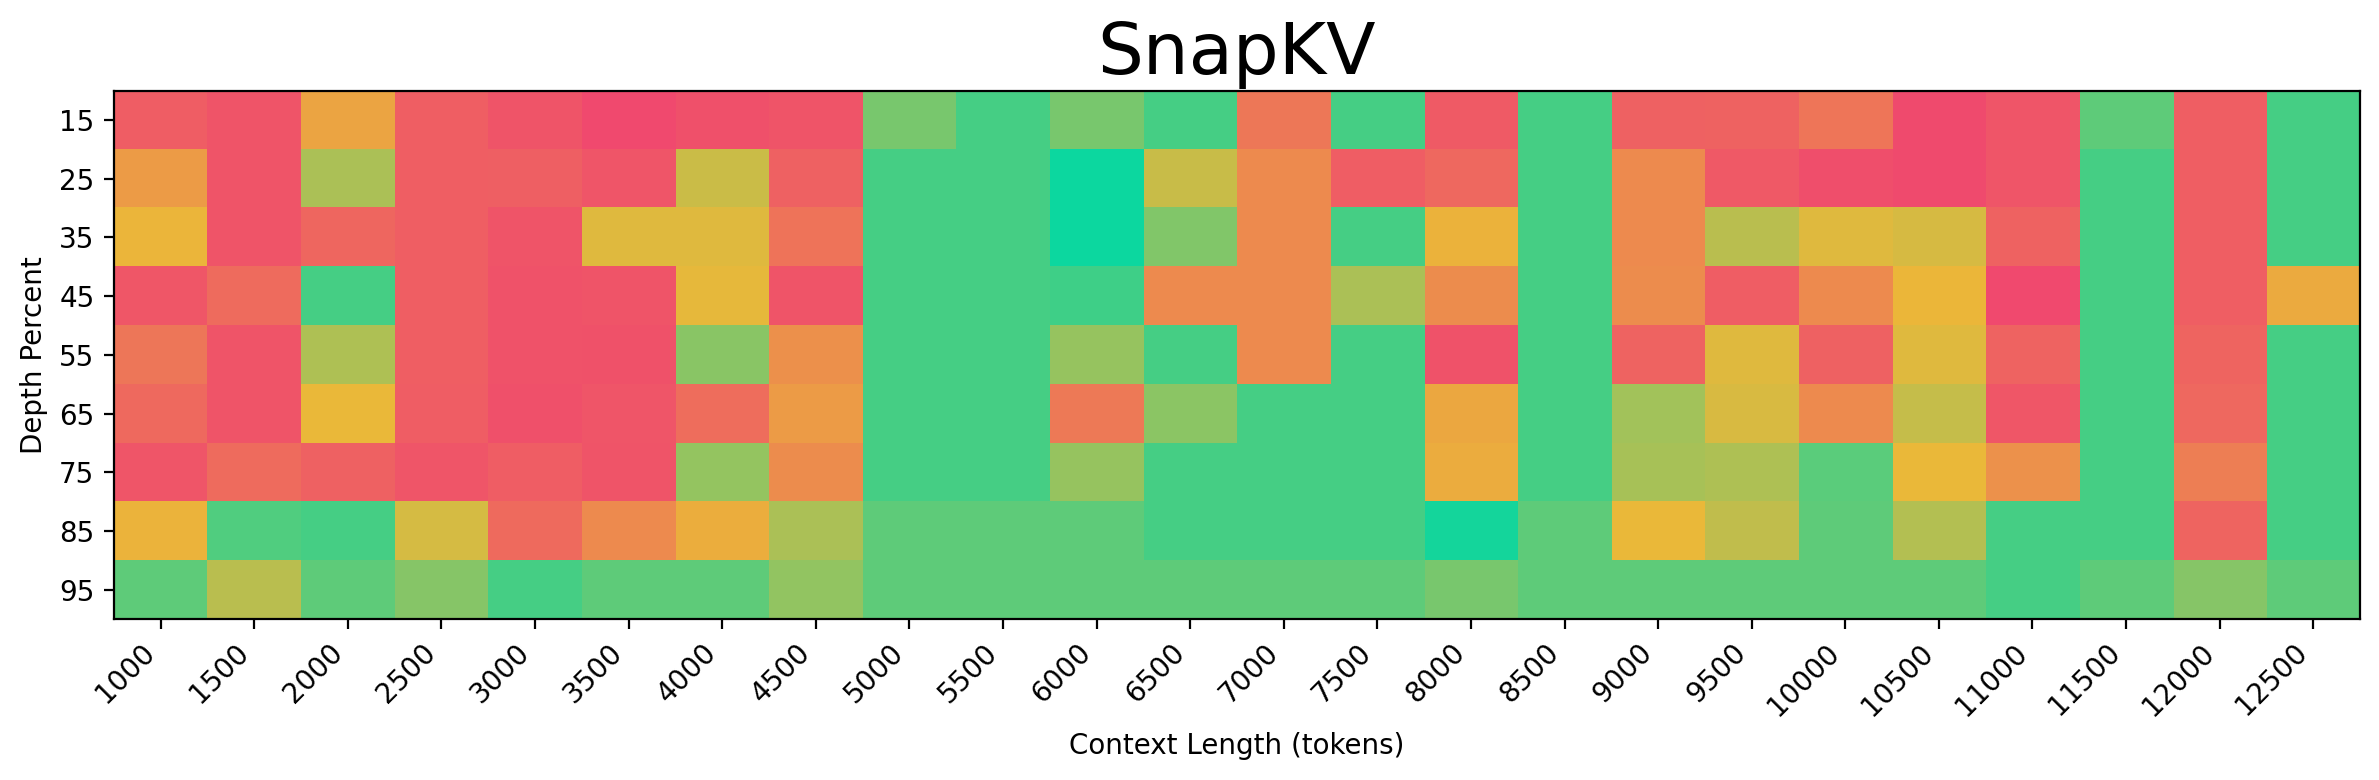

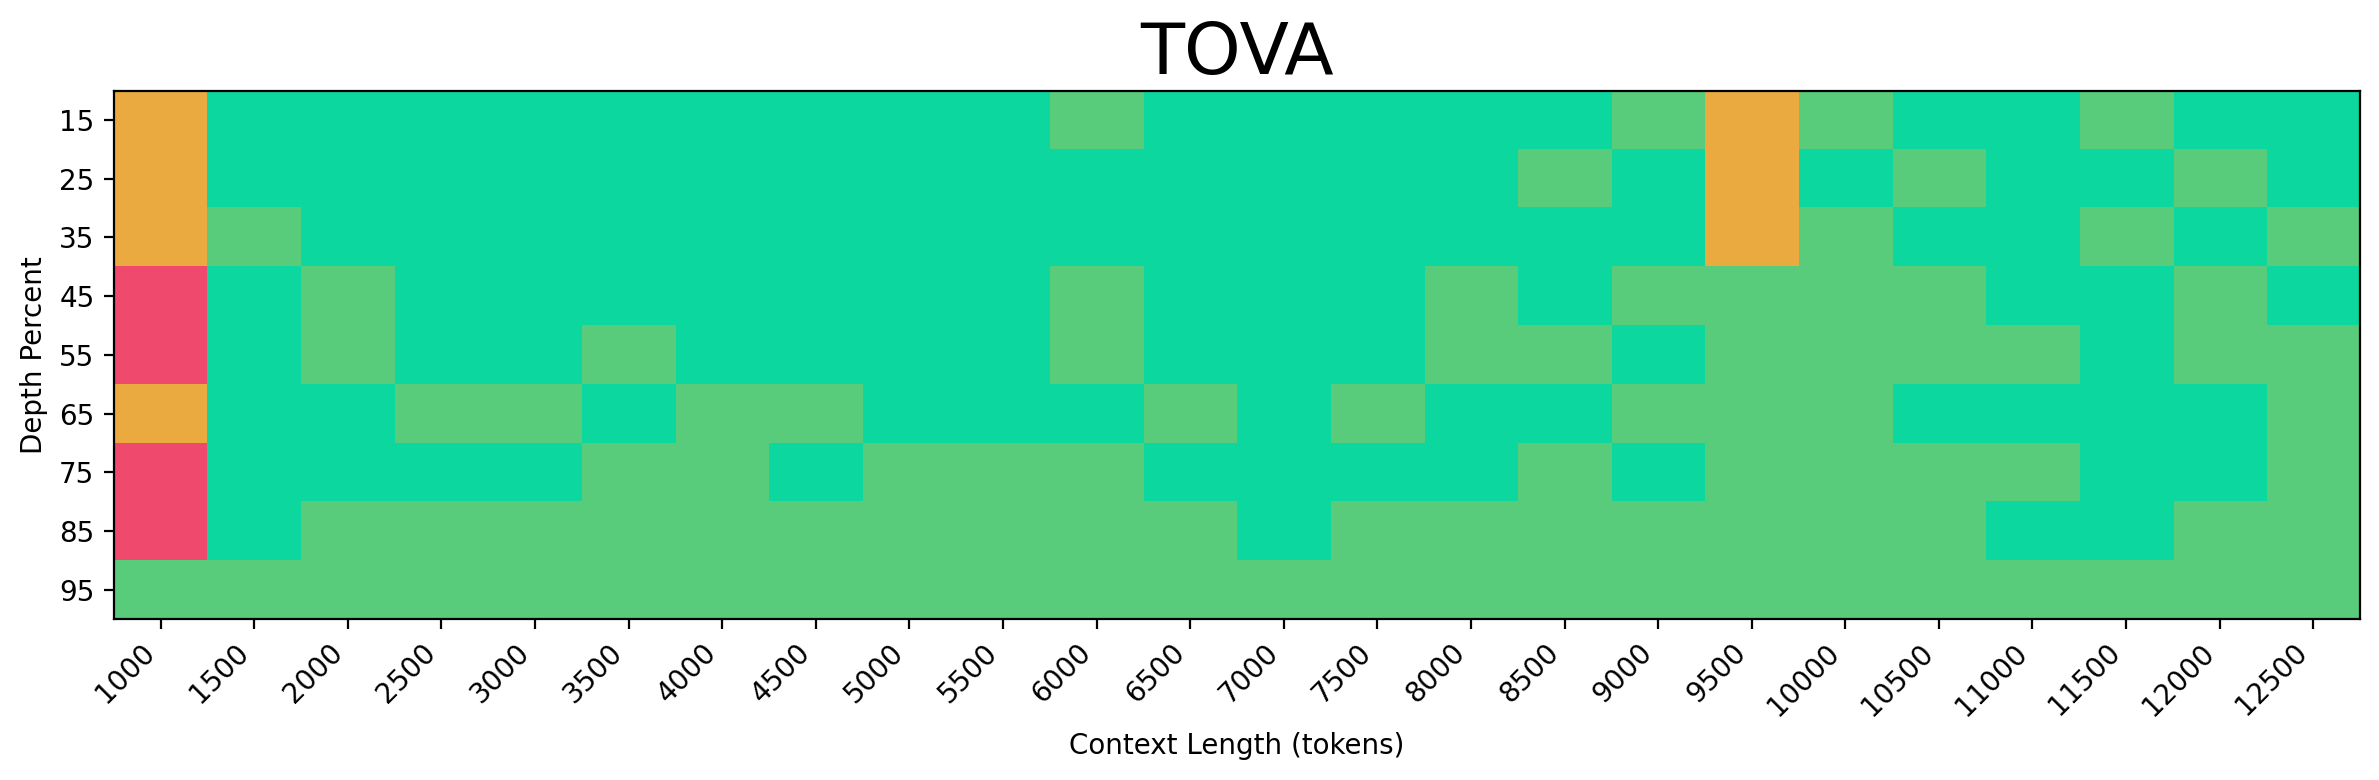

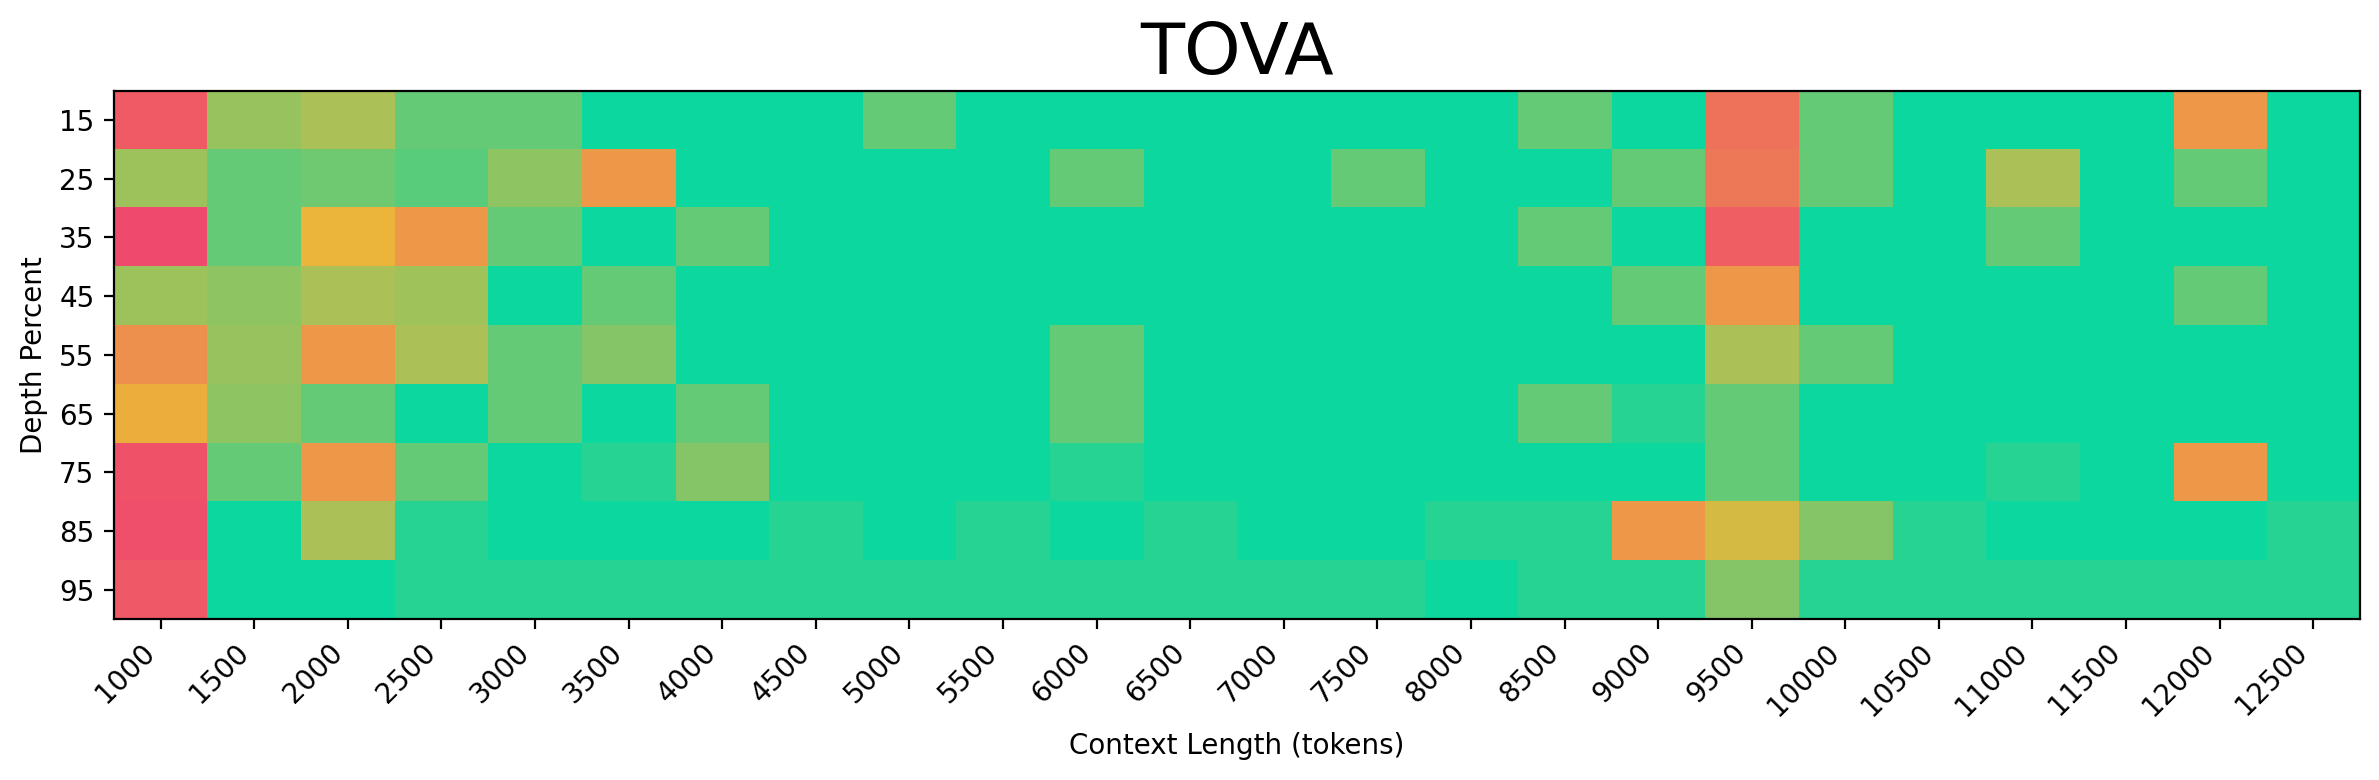

In [62]:
# ========= 收集点 =========
points = []  # press, cr, ctx, depth, score

for d in glob.glob(os.path.join(ROOT, "needle_in_haystack__*")):
    base = os.path.basename(d)
    m = DIR_RE.search(base)
    if not m:
        continue

    press = m.group("press")
    cr = float(m.group("cr"))
    ctx = int(m.group("ctx"))
    depth = int(m.group("depth"))

    mp = find_metrics_json(d)
    if mp is None:
        # 没找到 metrics：记 NaN（也可以选择直接跳过）
        score = float("nan")
    else:
        score = rougeL_f_from_metrics(mp)

    points.append((press, cr, ctx, depth, score))

if not points:
    raise RuntimeError(f"No NIAH results found under: {ROOT}")

dfp = pd.DataFrame(points, columns=["press", "cr", "ctx", "depth", "score"])
print(f"[INFO] collected points: {len(dfp)}")
print("[INFO] score stats (non-nan):",
      dfp["score"].dropna().describe().to_string() if dfp["score"].notna().any() else "ALL NaN")

# ========= 画图 =========
idx_depth = {d: i for i, d in enumerate(DEPTHS)}
idx_ctx = {c: i for i, c in enumerate(CONTEXTS)}

for (press, cr), g in dfp.groupby(["press", "cr"], sort=True):
    mat = np.full((len(DEPTHS), len(CONTEXTS)), np.nan, dtype=float)

    for _, r in g.iterrows():
        if r["depth"] in idx_depth and r["ctx"] in idx_ctx:
            mat[idx_depth[r["depth"]], idx_ctx[r["ctx"]]] = r["score"]

    # debug：看看是不是常数/全 NaN（避免又遇到“一片颜色”但不知道原因）
    non_nan = mat[~np.isnan(mat)]
    uniq = np.unique(non_nan) if non_nan.size else []
    print(f"[DEBUG] press={press} cr={cr:.2f} filled={non_nan.size}/{mat.size} unique(non-nan)={uniq[:10]}{'...' if len(uniq)>10 else ''}")

    # colormap：越好越绿，越差越红；NaN 灰色
    cmap = LinearSegmentedColormap.from_list("custom_cmap", ["#F0496E", "#EBB839", "#0CD79F"])
    cmap.set_bad(color="lightgray")  # NaN 显示灰色:contentReference[oaicite:3]{index=3}

    plt.figure(figsize=(12, 4), dpi=200)
    # im = sns.heatmap(
    #     mat,
    #     # aspect="auto",
    #     # interpolation="nearest",
    #     cmap=cmap,
    #     fmt="g"
    #     # vmin=0.0, vmax=1.0,   # 固定范围 0~1，避免 vmin≈vmax 导致色条怪:contentReference[oaicite:4]{index=4}
    # )
    im = plt.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=np.nanmin(mat), vmax=np.nanmax(mat)
        # vmin=0.0, vmax=1.0,   # 固定范围 0~1，避免 vmin≈vmax 导致色条怪:contentReference[oaicite:4]{index=4}
        # norm=matplotlib.colors.PowerNorm(gamma=0.7, vmin=0, vmax=1)
    )
    # plt.colorbar(im, label="Score")

    plt.xticks(range(len(CONTEXTS)), [str(c) for c in CONTEXTS], rotation=45, ha="right")
    plt.yticks(range(len(DEPTHS)), [str(d) for d in DEPTHS])
    plt.xlabel("Context Length (tokens)")
    plt.ylabel("Depth Percent")
    plt.title(f"{press_map[press]}", fontsize=26)

    out = os.path.join(OUT_DIR, f"niah__{press}__cr{cr:.2f}.svg")
    plt.tight_layout()
    plt.savefig(out, dpi=400)
    # plt.close()
    # print(f"[OK] saved: {out}")
